# Chargement fichier client

In [6]:
#Bibliothèques
import sqlite3
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt, gc
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, pairwise_distances_argmin
from sklearn.cluster import AgglomerativeClustering



In [7]:
DB_PATH = Path(r"C:\Users\lza\Documents\P04_Segmenter_Clients_E-Commerce\data\olist.db")
if not DB_PATH.exists():
    raise FileNotFoundError(f"DB introuvable : {DB_PATH}")

df_rfm = pd.read_csv("./exports/clients_features_raw.csv")
print(df_rfm.shape)
df_rfm.head()

(93358, 4)


,customer_unique_id,recency,frequency,monetary
0,0a0a92112bd4c708ca5fde585afaa872,334,1,13664.08
1,da122df9eeddfedc1dc1f5349a1a690c,515,2,7571.63
2,763c8b1c9c68a0229c42c9fc6f662b93,45,1,7274.88
3,dc4802a71eae9be1dd28f5d788ceb526,563,1,6929.31
4,459bef486812aa25204be022145caa62,35,1,6922.21


# Préparation X + scaling

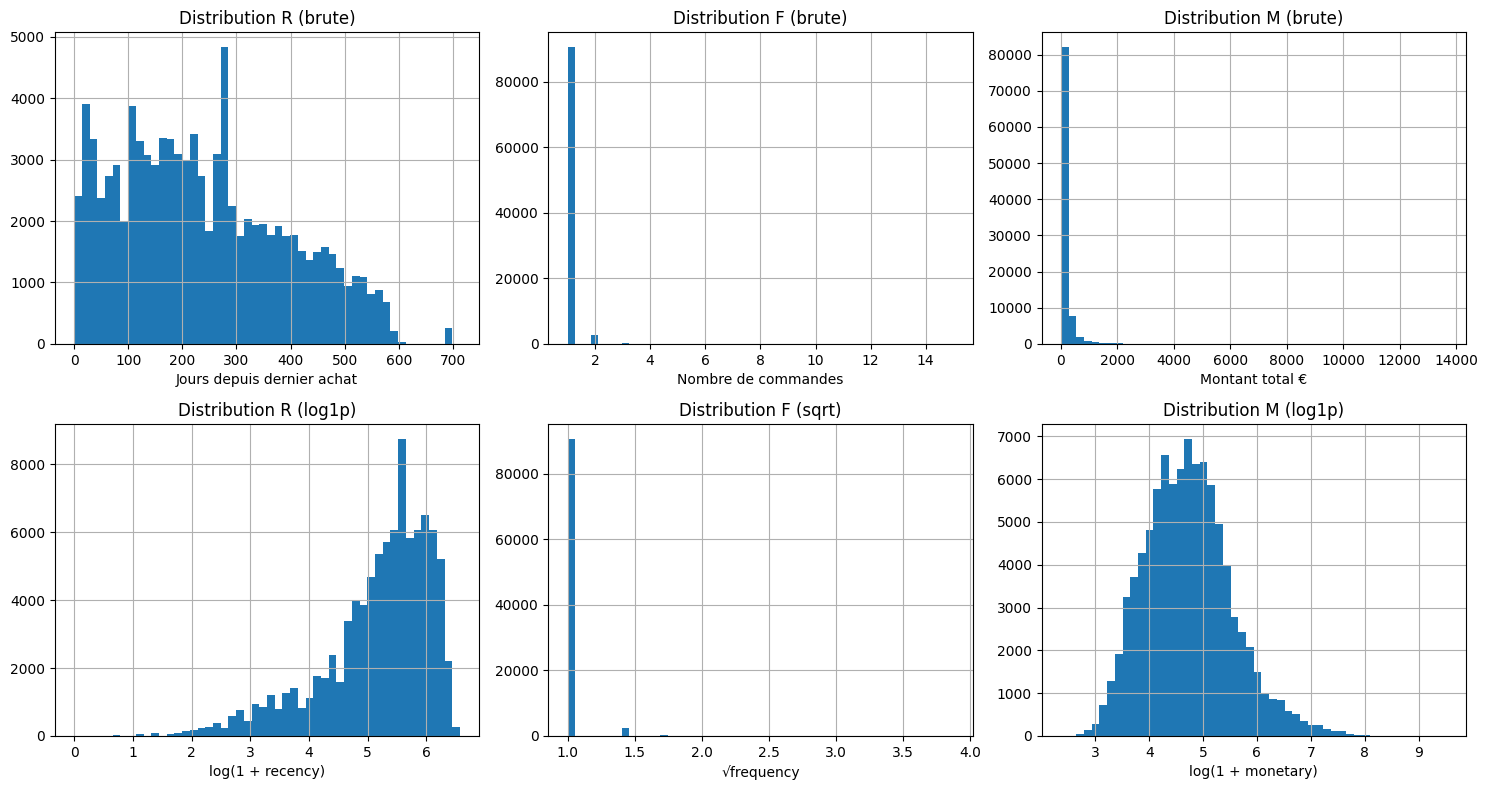

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# DISTRIBUTIONS ORIGINALES

df_rfm['recency'].hist(bins=50, ax=axes[0, 0])
axes[0, 0].set_title('Distribution R (brute)')
axes[0, 0].set_xlabel('Jours depuis dernier achat')

df_rfm['frequency'].hist(bins=50, ax=axes[0, 1])
axes[0, 1].set_title('Distribution F (brute)')
axes[0, 1].set_xlabel('Nombre de commandes')

df_rfm['monetary'].hist(bins=50, ax=axes[0, 2])
axes[0, 2].set_title('Distribution M (brute)')
axes[0, 2].set_xlabel('Montant total €')

# TRANSFORMATIONS

R_transformed = np.log1p(df_rfm['recency']) 
F_transformed = np.sqrt(df_rfm['frequency'])
M_transformed = np.log1p(df_rfm['monetary'])


# DISTRIBUTIONS TRANSFORMÉES 

R_transformed.hist(bins=50, ax=axes[1, 0])
axes[1, 0].set_title('Distribution R (log1p)')
axes[1, 0].set_xlabel('log(1 + recency)')

F_transformed.hist(bins=50, ax=axes[1, 1])
axes[1, 1].set_title('Distribution F (sqrt)')
axes[1, 1].set_xlabel('√frequency')

M_transformed.hist(bins=50, ax=axes[1, 2])
axes[1, 2].set_title('Distribution M (log1p)')
axes[1, 2].set_xlabel('log(1 + monetary)')

plt.tight_layout()
plt.show()


# Standardisation pour le clustering

X = np.column_stack([R_transformed, F_transformed, M_transformed])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)




# Clustering

# K-Means 

K-MEANS CLUSTERING
k=2 → silhouette=0.713, inertia=192019
k=3 → silhouette=0.421, inertia=131068
k=4 → silhouette=0.395, inertia=84731
k=5 → silhouette=0.359, inertia=70142
k=6 → silhouette=0.355, inertia=60249
k=7 → silhouette=0.354, inertia=53071
k=8 → silhouette=0.356, inertia=47363


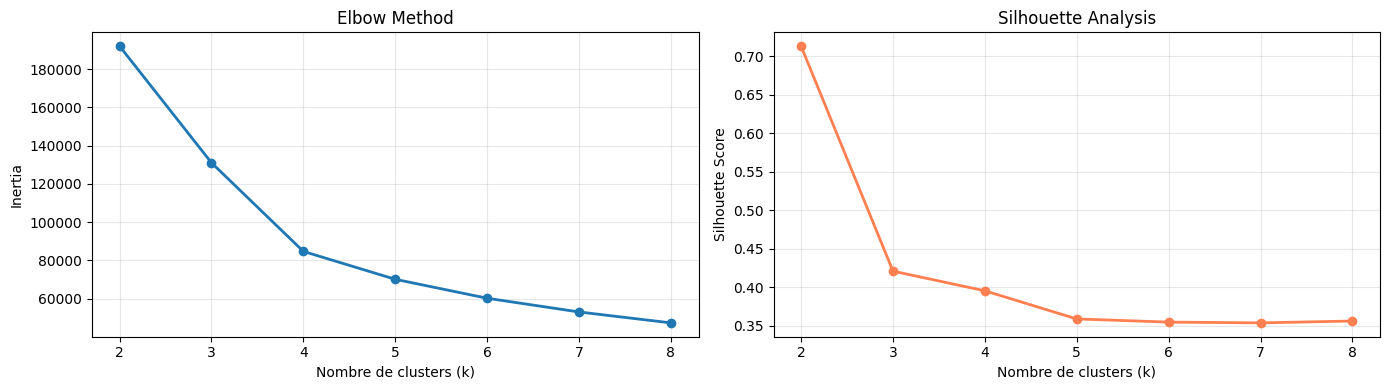


✓ K-Means appliqué avec k=4
cluster_kmeans
0    32201
1    42323
2    16033
3     2801
Name: count, dtype: int64


In [9]:

print("K-MEANS CLUSTERING")

# Tester plusieurs k
silhouette_scores = []
inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    silhouette = silhouette_score(X_scaled, labels)
    silhouette_scores.append(silhouette)
    inertias.append(km.inertia_)
    
    print(f"k={k} → silhouette={silhouette:.3f}, inertia={km.inertia_:.0f}")

# Visualiser elbow + silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(k_range, inertias, marker='o', linewidth=2)
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, marker='o', linewidth=2, color='coral')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Appliquer le meilleur k - ici 4
BEST_K = 4 
kmeans_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df_rfm['cluster_kmeans'] = kmeans_final.fit_predict(X_scaled)

print(f"\n✓ K-Means appliqué avec k={BEST_K}")
print(df_rfm['cluster_kmeans'].value_counts().sort_index())

DBSCAN CLUSTERING


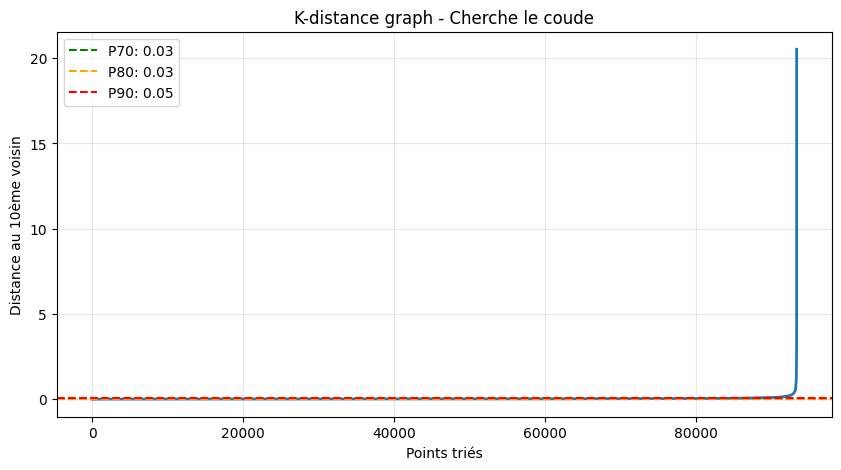


Test de différents epsilon :
eps=0.026 → 303 clusters | 21.4% bruit | silhouette=-0.394
eps=0.029 → 286 clusters | 17.6% bruit | silhouette=-0.354
eps=0.034 → 292 clusters | 13.7% bruit | silhouette=-0.361
eps=0.040 → 211 clusters | 10.1% bruit | silhouette=-0.369
eps=0.052 → 144 clusters | 6.9% bruit | silhouette=-0.337

 Pas de solution optimale, utilisation de eps=0.034

✓ DBSCAN appliqué : 292 clusters, 12,806 points de bruit (13.7%)

Distribution des clusters :
cluster_dbscan
-1      12806
 0         13
 1         15
 2         20
 3         23
        ...  
 287        8
 288       14
 289       11
 290       13
 291       12
Name: count, Length: 293, dtype: int64

PROFIL DES CLUSTERS DBSCAN (hors bruit)
                R_median  F_median  M_median    CA_total  n_clients
cluster_dbscan                                                     
45                 254.0       1.0   101.730  9077759.92      73142
90                  39.0       1.0   114.770   259869.64       2167
17     

In [10]:

# CLUSTERING DBSCAN

print("DBSCAN CLUSTERING")

# Trouver epsilon optimal
MIN_SAMPLES = 10

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES + 1, metric="euclidean").fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

# Visualiser k-distance pour choisir epsilon
plt.figure(figsize=(10, 5))
plt.plot(k_distances, linewidth=2)
plt.axhline(y=np.percentile(k_distances, 70), color='g', linestyle='--', 
            label=f'P70: {np.percentile(k_distances, 70):.2f}')
plt.axhline(y=np.percentile(k_distances, 80), color='orange', linestyle='--', 
            label=f'P80: {np.percentile(k_distances, 80):.2f}')
plt.axhline(y=np.percentile(k_distances, 90), color='r', linestyle='--', 
            label=f'P90: {np.percentile(k_distances, 90):.2f}')
plt.xlabel('Points triés')
plt.ylabel(f'Distance au {MIN_SAMPLES}ème voisin')
plt.title('K-distance graph - Cherche le coude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Tester plusieurs epsilon
print("\nTest de différents epsilon :")
eps_tests = [
    np.percentile(k_distances, 70),
    np.percentile(k_distances, 75),
    np.percentile(k_distances, 80),
    np.percentile(k_distances, 85),
    np.percentile(k_distances, 90)
]

best_eps = None
best_score = -1
best_n_clusters = 0

for eps in eps_tests:
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    pct_noise = n_noise / len(labels) * 100
    
    # Calculer silhouette si possible
    mask = labels != -1
    if mask.sum() > 0 and n_clusters > 1:
        sil = silhouette_score(X_scaled[mask], labels[mask])
        sil_str = f"{sil:.3f}"
        
        # Garder le meilleur (3-8 clusters, <25% bruit)
        if 3 <= n_clusters <= 8 and pct_noise < 25 and sil > best_score:
            best_score = sil
            best_eps = eps
            best_n_clusters = n_clusters
    else:
        sil_str = "N/A"
    
    print(f"eps={eps:.3f} → {n_clusters} clusters | {pct_noise:.1f}% bruit | silhouette={sil_str}")

# Si pas de bon epsilon trouvé, prendre P80 par défaut
if best_eps is None:
    best_eps = np.percentile(k_distances, 80)
    print(f"\n Pas de solution optimale, utilisation de eps={best_eps:.3f}")
else:
    print(f"\n Meilleur epsilon : {best_eps:.3f} ({best_n_clusters} clusters)")

# Appliquer DBSCAN final
dbscan = DBSCAN(eps=best_eps, min_samples=MIN_SAMPLES)
df_rfm['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df_rfm['cluster_dbscan'])) - (1 if -1 in df_rfm['cluster_dbscan'].values else 0)
n_noise = (df_rfm['cluster_dbscan'] == -1).sum()
pct_noise = n_noise / len(df_rfm) * 100

print(f"\n✓ DBSCAN appliqué : {n_clusters_db} clusters, {n_noise:,} points de bruit ({pct_noise:.1f}%)")
print("\nDistribution des clusters :")
print(df_rfm['cluster_dbscan'].value_counts().sort_index())

# Profiling DBSCAN (hors bruit)
mask_no_noise = df_rfm['cluster_dbscan'] != -1

if mask_no_noise.sum() > 0 and n_clusters_db > 0:
   
    profile_db = df_rfm[mask_no_noise].groupby('cluster_dbscan').agg({
        'recency': 'median',          # Utiliser les colonnes R, F, M
        'frequency': 'median',
        'monetary': ['median', 'sum']
            
    })
    
    # Correction du renommage des colonnes
    profile_db.columns = ['R_median', 'F_median', 'M_median', 'CA_total']
    
    # Ajouter le nombre de clients
    profile_db['n_clients'] = df_rfm[mask_no_noise].groupby('cluster_dbscan').size()
    
    profile_db = profile_db.sort_values('CA_total', ascending=False)
    
    print("\n" + "=" * 70)
    print("PROFIL DES CLUSTERS DBSCAN (hors bruit)")
    print("=" * 70)
    print(profile_db)


COMPARAISON K-MEANS vs DBSCAN

 MÉTRIQUES GLOBALES
----------------------------------------------------------------------
Méthode         N Clusters   % Bruit      Silhouette  
----------------------------------------------------------------------
K-Means         4            0%           0.395
DBSCAN          292          13.7%        -0.361
----------------------------------------------------------------------

 PROFILS DES CLUSTERS - K-MEANS
----------------------------------------------------------------------
                n_clients  R_median  F_median  M_median    CA_total
cluster_kmeans                                                     
0                   32201     254.0       1.0    199.27  9519670.09
1                   42323     269.0       1.0     65.84  2885451.75
2                   16033      37.0       1.0    103.89  2150464.45
3                    2801     199.0       2.0    225.55   864187.46

 PROFILS DES CLUSTERS - DBSCAN (hors bruit)
--------------------------

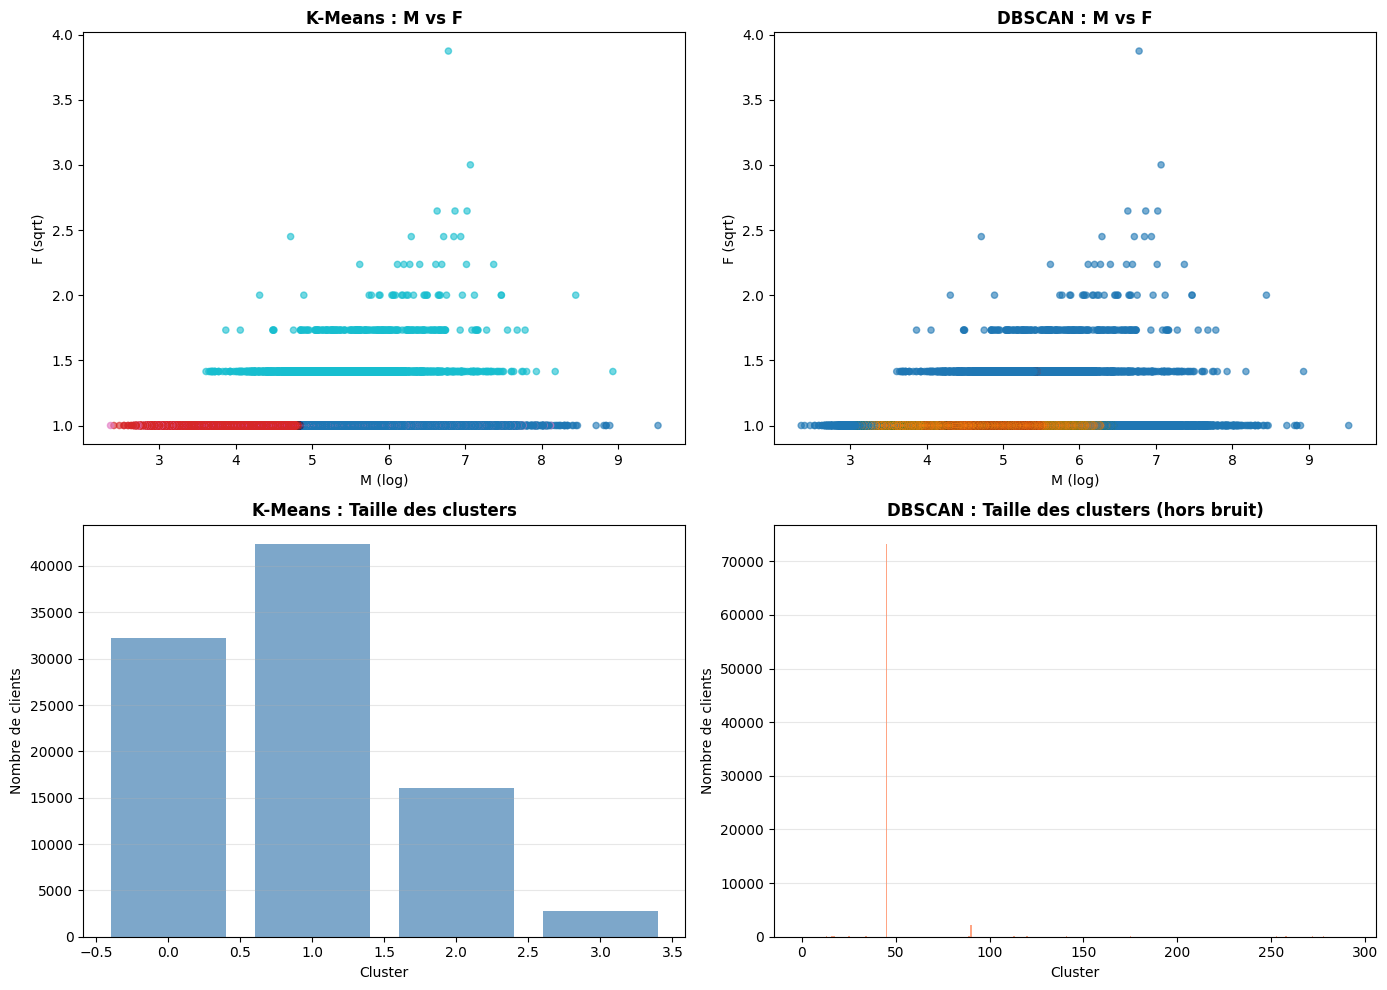


 RECOMMANDATION
 K-MEANS recommandé
  - Meilleure silhouette (0.395 vs -0.361)
  - 4 clusters équilibrés
  - Tous les clients assignés

 Colonne 'cluster_final' créée avec K-Means


In [11]:

# COMPARAISON K-MEANS vs DBSCAN

print("\n" + "=" * 70)
print("COMPARAISON K-MEANS vs DBSCAN")
print("=" * 70)

# Calcul des métriques comparatives
# Silhouette K-Means
sil_kmeans = silhouette_score(X_scaled, df_rfm['cluster_kmeans'])

# Silhouette DBSCAN (hors bruit)
mask_no_noise = df_rfm['cluster_dbscan'] != -1
n_clusters_db = len(df_rfm[mask_no_noise]['cluster_dbscan'].unique())

if n_clusters_db > 1:
    sil_dbscan = silhouette_score(X_scaled[mask_no_noise], 
                                  df_rfm.loc[mask_no_noise, 'cluster_dbscan'])
else:
    sil_dbscan = np.nan

# Résumé des métriques
print("\n MÉTRIQUES GLOBALES")
print("-" * 70)
print(f"{'Méthode':<15} {'N Clusters':<12} {'% Bruit':<12} {'Silhouette':<12}")
print("-" * 70)
print(f"{'K-Means':<15} {BEST_K:<12} {'0%':<12} {sil_kmeans:.3f}")

n_noise = (df_rfm['cluster_dbscan'] == -1).sum()
pct_noise = n_noise / len(df_rfm) * 100
sil_db_str = f"{sil_dbscan:.3f}" if not np.isnan(sil_dbscan) else "N/A"
print(f"{'DBSCAN':<15} {n_clusters_db:<12} {f'{pct_noise:.1f}%':<12} {sil_db_str}")
print("-" * 70)

# Profils détaillés
print("\n PROFILS DES CLUSTERS - K-MEANS")
print("-" * 70)
profile_km = df_rfm.groupby('cluster_kmeans').agg({
    'customer_unique_id': 'count',
    'recency': 'median',
    'frequency': 'median',
    'monetary': ['median', 'sum']
}).round(2)
profile_km.columns = ['n_clients', 'R_median', 'F_median', 'M_median', 'CA_total']
profile_km = profile_km.sort_values('CA_total', ascending=False)
print(profile_km)

if n_clusters_db > 0:
    print("\n PROFILS DES CLUSTERS - DBSCAN (hors bruit)")
    print("-" * 70)
    profile_db = df_rfm[mask_no_noise].groupby('cluster_dbscan').agg({
        'customer_unique_id': 'count',
        'recency': 'median',
        'frequency': 'median',
        'monetary': ['median', 'sum']
    }).round(2)
    profile_db.columns = ['n_clients', 'R_median', 'F_median', 'M_median', 'CA_total']
    profile_db = profile_db.sort_values('CA_total', ascending=False)
    print(profile_db)
    print(f" Points de bruit exclus : {n_noise:,} clients ({pct_noise:.1f}%)")

# Visualisation comparative
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plots

axes[0, 0].scatter(M_transformed, F_transformed, 
                   c=df_rfm['cluster_kmeans'], cmap='tab10', alpha=0.6, s=20)
axes[0, 0].set_xlabel('M (log)')
axes[0, 0].set_ylabel('F (sqrt)')
axes[0, 0].set_title('K-Means : M vs F', fontweight='bold')

axes[0, 1].scatter(M_transformed, F_transformed, 
                   c=df_rfm['cluster_dbscan'], cmap='tab10', alpha=0.6, s=20)
axes[0, 1].set_xlabel('M (log)')
axes[0, 1].set_ylabel('F (sqrt)')
axes[0, 1].set_title('DBSCAN : M vs F', fontweight='bold')

# Bar charts
axes[1, 0].bar(profile_km.index, profile_km['n_clients'], color='steelblue', alpha=0.7)
axes[1, 0].set_title('K-Means : Taille des clusters', fontweight='bold')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Nombre de clients')
axes[1, 0].grid(True, alpha=0.3, axis='y')

if n_clusters_db > 0:
    axes[1, 1].bar(profile_db.index, profile_db['n_clients'], color='coral', alpha=0.7)
    axes[1, 1].set_title('DBSCAN : Taille des clusters (hors bruit)', fontweight='bold')
else:
    axes[1, 1].text(0.5, 0.5, 'DBSCAN : Segmentation non exploitable', 
                    ha='center', va='center', fontsize=12)
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Nombre de clients')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Décision automatique
print("\n" + "=" * 70)
print(" RECOMMANDATION")
print("=" * 70)

# Critères de décision
kmeans_ok = True  # K-Means fonctionne toujours
dbscan_ok = (n_clusters_db >= 3 and pct_noise < 20 and not np.isnan(sil_dbscan))

if dbscan_ok and sil_dbscan > sil_kmeans:
    print(" DBSCAN recommandé")
    print(f"  - Meilleure silhouette ({sil_dbscan:.3f} vs {sil_kmeans:.3f})")
    print(f"  - Détecte {pct_noise:.1f}% d'outliers")
    print(f"  - {n_clusters_db} clusters exploitables")
    df_rfm['cluster_final'] = df_rfm['cluster_dbscan']
    CHOSEN_METHOD = 'DBSCAN'
else:
    print(" K-MEANS recommandé")
    if not dbscan_ok:
        if n_clusters_db < 3:
            print(f"  - DBSCAN : trop peu de clusters ({n_clusters_db})")
        if pct_noise >= 20:
            print(f"  - DBSCAN : trop de bruit ({pct_noise:.1f}%)")
    else:
        print(f"  - Meilleure silhouette ({sil_kmeans:.3f} vs {sil_dbscan:.3f})")
    print(f"  - {BEST_K} clusters équilibrés")
    print("  - Tous les clients assignés")
    df_rfm['cluster_final'] = df_rfm['cluster_kmeans']
    CHOSEN_METHOD = 'K-Means'

print(f"\n Colonne 'cluster_final' créée avec {CHOSEN_METHOD}")
#K-means
#Segment majoritaire : clients occasionnels / à faible valeur
#Segments moyens : clients “classiques” réguliers
#Petit segment : clients premium ou récents à surveiller

In [12]:
print("\n" + "=" * 70)
print(" MODÈLE RETENU : K-MEANS")
print("=" * 70)

# Garder uniquement K-Means
df_rfm['cluster_final'] = df_rfm['cluster_kmeans']

print(f" {BEST_K} segments créés")
print(f" Silhouette score : {sil_kmeans:.3f}")
print("\n Distribution des segments :")
print(df_rfm['cluster_final'].value_counts().sort_index())

# Profil détaillé final
profile_final = df_rfm.groupby('cluster_final').agg({
    'customer_unique_id': 'count',
    'recency': ['mean', 'median'],
    'frequency': ['mean', 'median'],
    'monetary': ['mean', 'median', 'sum']
}).round(2)

profile_final.columns = ['n_clients', 'R_mean', 'R_median', 
                         'F_mean', 'F_median', 'M_mean', 'M_median', 'CA_total']
profile_final = profile_final.sort_values('CA_total', ascending=False)

print("\n" + "=" * 70)
print("PROFIL DES SEGMENTS")
print("=" * 70)
print(profile_final)





 MODÈLE RETENU : K-MEANS
 4 segments créés
 Silhouette score : 0.395

 Distribution des segments :
cluster_final
0    32201
1    42323
2    16033
3     2801
Name: count, dtype: int64

PROFIL DES SEGMENTS
               n_clients  R_mean  R_median  F_mean  F_median  M_mean  \
cluster_final                                                          
0                  32201  272.10     254.0    1.00       1.0  295.63   
1                  42323  286.58     269.0    1.00       1.0   68.18   
2                  16033   41.41      37.0    1.00       1.0  134.13   
3                   2801  219.81     199.0    2.11       2.0  308.53   

               M_median    CA_total  
cluster_final                        
0                199.27  9519670.09  
1                 65.84  2885451.75  
2                103.89  2150464.45  
3                225.55   864187.46  


# Comprendre et analyser les profils type clients actuels

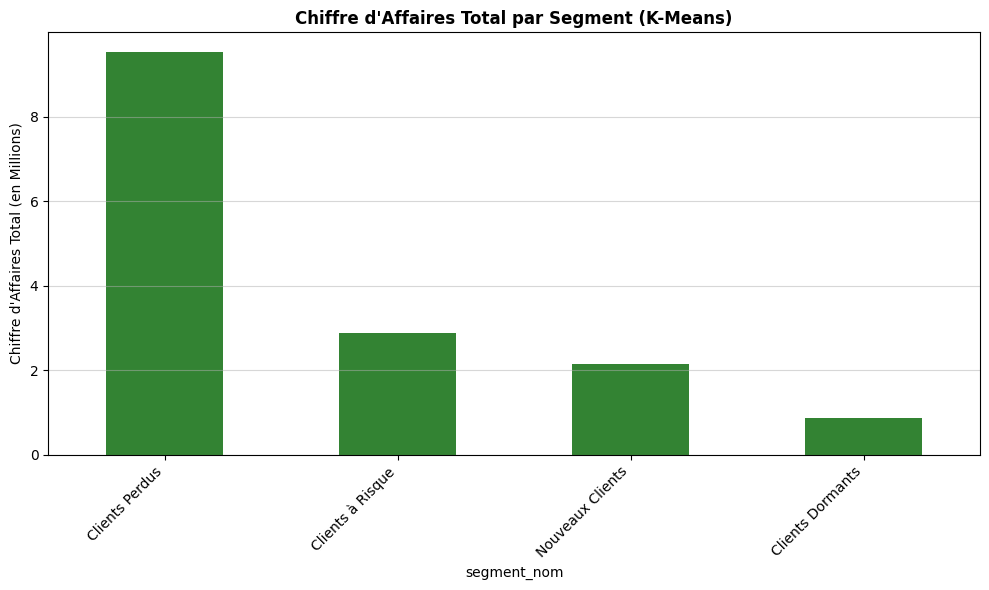

In [13]:
segment_map = {
    1: 'Clients à Risque',
    2: 'Nouveaux Clients',
    3: 'Clients Dormants',
    0: 'Clients Perdus'
}

# 2. Appliquer ce mapping pour créer une nouvelle colonne
# Bonne pratique de créer une nouvelle colonne pour garder l'originale!!
df_rfm['segment_nom'] = df_rfm['cluster_final'].map(segment_map)
# Create the missing Bar Chart for total revenue (CA_total) per cluster
ca_par_segment = df_rfm.groupby('segment_nom')['monetary'].sum() / 1_000_000
ca_par_segment = ca_par_segment.sort_values(ascending=False)
# Ensure the plot is clean and informative
plt.figure(figsize=(10, 6))
ca_par_segment.plot(kind='bar', color='darkgreen', alpha=0.8)

plt.title('Chiffre d\'Affaires Total par Segment (K-Means)', fontweight='bold')
plt.ylabel('Chiffre d\'Affaires Total (en Millions)')
plt.xticks(rotation=45, ha='right') # Keep labels horizontal
plt.grid(True, axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('CA_par_segment_nom.png')

# Visualisation des profils : radar plot

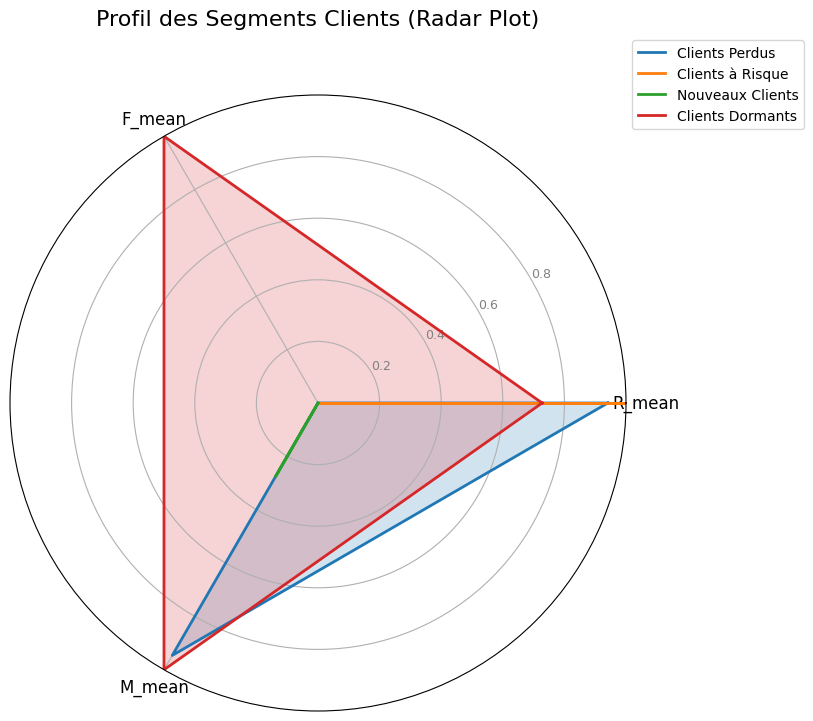

In [14]:

# On sélectionne les colonnes moyennes qui nous intéressent pour la visualisation
profile_for_plot = profile_final[['R_mean', 'F_mean', 'M_mean']].copy()

# Utilisation du MinMaxScaler pour ramener toutes les valeurs entre 0 et 1
scaler = MinMaxScaler()
profile_scaled = pd.DataFrame(scaler.fit_transform(profile_for_plot), 
                              columns=profile_for_plot.columns, 
                              index=profile_for_plot.index)

# --- 2. Création du Radar Plot ---

# Variables pour le graphique
labels = profile_scaled.columns
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Répéter le premier angle à la fin pour fermer le polygone

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Boucle pour tracer chaque segment
for i, row in profile_scaled.iterrows():
    values = row.tolist()
    values += values[:1] # Répéter la première valeur pour fermer le polygone
    # On utilise le mapping pour obtenir le nom du segment au lieu de son numéro 'i'
    segment_name = segment_map.get(i, f'Segment {i}') # .get() est plus sûr
    ax.plot(angles, values, label=segment_name, linewidth=2)
    ax.fill(angles, values, alpha=0.2)

# Ajout des labels pour chaque axe
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=12)

# Ajustement de l'axe y (les cercles concentriques)
ax.set_rlabel_position(30)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="grey", size=9)
plt.ylim(0, 1)

# Titre et légende
plt.title('Profil des Segments Clients (Radar Plot)', size=16, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

In [15]:
#R_mean (Récence) : Un score de 1 est mauvais (client très ancien, inactif). Un score de 0 est excellent (client très récent).

#F_mean (Fréquence) : Un score de 1 est excellent (achats fréquents).

#M_mean (Monétaire) : Un score de 1 est excellent (dépenses élevées).

#La surface du polygone d'un segment représente sa "valeur" globale : une grande surface est synonyme de clients historiquement importants.

Analyse K-means avec nouvelle feature : review_score

In [16]:
DB_PATH = Path(r"C:\Users\lza\Documents\P04_Segmenter_Clients_E-Commerce\data\olist.db")

# Vérifier si le fichier existe
if not DB_PATH.exists():
    raise FileNotFoundError(f"Fichier de base de données introuvable : {DB_PATH}")

# Établir la connexion
try:
    conn = sqlite3.connect(DB_PATH)
    print(" Connexion à la base de données Olist réussie.")
except sqlite3.Error as e:
    print(f" Erreur de connexion : {e}")

# REQUÊTE SQL POUR EXTRAIRE LES DONNÉES RFM + REVIEW SCORE
sql_client_file = """
WITH delivered AS (
  SELECT o.order_id, o.customer_id, c.customer_unique_id, DATE(o.order_purchase_timestamp) AS purchase_ts
  FROM orders o JOIN customers c ON o.customer_id = c.customer_id
  WHERE o.order_status = 'delivered'
),
per_order_value AS (
  SELECT d.order_id, SUM(oi.price + oi.freight_value) AS order_value
  FROM delivered d JOIN order_items oi ON oi.order_id = d.order_id
  GROUP BY d.order_id
),
rfm_base AS (
  SELECT
    d.customer_unique_id,
    MAX(d.purchase_ts) AS last_order_date,
    COUNT(DISTINCT d.order_id) AS n_orders,
    SUM(pov.order_value) AS m_amount_total
  FROM delivered d JOIN per_order_value pov ON pov.order_id = d.order_id
  GROUP BY d.customer_unique_id
),
review_mean AS (
  SELECT d.customer_unique_id, AVG(CAST(rw.review_score AS REAL)) AS review_score_mean
  FROM order_reviews rw JOIN delivered d ON d.order_id = rw.order_id
  GROUP BY d.customer_unique_id
)
SELECT
  r.customer_unique_id,
  CAST(JULIANDAY((SELECT MAX(purchase_ts) FROM delivered)) - JULIANDAY(r.last_order_date) AS INTEGER) AS days_since_last_order,
  r.n_orders,
  r.m_amount_total,
  rm.review_score_mean
FROM rfm_base r
LEFT JOIN review_mean rm ON rm.customer_unique_id = r.customer_unique_id;
"""

# CHARGEMENT ET PRÉPARATION DES DONNÉES
print("\n Chargement des données...")
df_clients = pd.read_sql_query(sql_client_file, conn)

# Renommage cohérent des colonnes
df_rfm = df_clients.rename(columns={
    'days_since_last_order': 'recency',
    'n_orders': 'frequency',
    'm_amount_total': 'monetary',
    'review_score_mean': 'review_score' 
})

# Gestion des valeurs manquantes pour review_score
review_median = df_rfm['review_score'].median()
df_rfm['review_score'] = df_rfm['review_score'].fillna(review_median)
print(f" Valeurs manquantes de 'review_score' remplacées par la médiane : {review_median:.2f}")

print(f"\n DataFrame prêt : {df_rfm.shape[0]} clients, {df_rfm.shape[1]} colonnes")
print("\nAperçu des données :")
print(df_rfm[['customer_unique_id', 'recency', 'frequency', 'monetary', 'review_score']].head())

 Connexion à la base de données Olist réussie.

 Chargement des données...
 Valeurs manquantes de 'review_score' remplacées par la médiane : 5.00

 DataFrame prêt : 93358 clients, 5 colonnes

Aperçu des données :
                 customer_unique_id  recency  frequency  monetary  \
0  0000366f3b9a7992bf8c76cfdf3221e2      111          1    141.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      114          1     27.19   
2  0000f46a3911fa3c0805444483337064      537          1     86.22   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89   

   review_score  
0           5.0  
1           4.0  
2           3.0  
3           4.0  
4           5.0  


In [17]:
# ANALYSE K-MEANS AVEC FEATURES ÉTENDUES
print("\n" + "="*70)
print("ANALYSE K-MEANS AVEC RFM + REVIEW SCORE")
print("="*70)

# Vérifier les colonnes disponibles
print("\nColonnes disponibles :")
for col in df_rfm.columns:
    print(f"   {col}")

# Préparer les features pour le clustering
base_features = ['recency', 'frequency', 'monetary']
additional_features = ['review_score']
all_features = base_features + additional_features

# Créer le dataframe pour le clustering
df_clustering = df_rfm[['customer_unique_id'] + all_features].copy()

print(f"\n Features utilisées pour le clustering : {', '.join(all_features)}")

# TRANSFORMATIONS POUR NORMALISER LES DISTRIBUTIONS
print("\n Application des transformations...")

# Recency : log transformation
recency_transformed = np.log1p(df_clustering['recency'])

# Frequency : racine carrée
frequency_transformed = np.sqrt(df_clustering['frequency'])

# Monetary : log transformation
monetary_transformed = np.log1p(df_clustering['monetary'])

# Review score : pas de transformation (échelle 1-5)
review_score_values = df_clustering['review_score'].values

# Créer la matrice de features
X = np.column_stack([
    recency_transformed,
    frequency_transformed,
    monetary_transformed,
    review_score_values
])

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f" Matrice créée : {X_scaled.shape[0]} clients × {X_scaled.shape[1]} features")

# RECHERCHE DU NOMBRE OPTIMAL DE CLUSTERS
print("\n" + "="*50)
print("RECHERCHE DU NOMBRE OPTIMAL DE CLUSTERS")
print("="*50)

silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)
    print(f"  k={k} clusters → Silhouette Score = {sil_score:.3f}")

# Sélection du meilleur k
best_k = k_range[np.argmax(silhouette_scores)]
best_silhouette = max(silhouette_scores)

print(f"\n Meilleur résultat : k={best_k} (Silhouette={best_silhouette:.3f})")

# APPLICATION DU K-MEANS FINAL
print("\n" + "="*50)
print(f"APPLICATION DU K-MEANS AVEC {best_k} CLUSTERS")
print("="*50)

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clustering['cluster'] = kmeans_final.fit_predict(X_scaled)

# PROFILING DES CLUSTERS
profile = df_clustering.groupby('cluster').agg({
    'recency': 'median',
    'frequency': 'median',
    'monetary': ['median', 'sum'],
    'review_score': 'median'
}).round(2)

# Renommer les colonnes
profile.columns = [
    'Recency_médiane',
    'Frequency_médiane',
    'Monetary_médian',
    'CA_total',
    'Review_médian'
]

# Ajouter le nombre et pourcentage de clients
profile['Nb_clients'] = df_clustering.groupby('cluster').size()
profile['%_clients'] = (profile['Nb_clients'] / len(df_clustering) * 100).round(1)

# Trier par CA total
profile = profile.sort_values('CA_total', ascending=False)

print("\n" + "=" * 80)
print("PROFIL DES CLUSTERS")
print("=" * 80)
print(profile)

# INTERPRÉTATION MÉTIER
print("\n" + "=" * 80)
print("INTERPRÉTATION MÉTIER DES CLUSTERS")
print("=" * 80)

for cluster_id in profile.index:
    cluster_data = profile.loc[cluster_id]
    
    # Logique pour nommer les segments
    if cluster_data['Monetary_médian'] > profile['Monetary_médian'].quantile(0.75):
        if cluster_data['Review_médian'] >= 4:
            segment_name = " VIP Satisfaits"
        else:
            segment_name = " Gros Acheteurs à Fidéliser"
    elif cluster_data['Frequency_médiane'] > profile['Frequency_médiane'].median():
        if cluster_data['Review_médian'] >= 4:
            segment_name = " Clients Fidèles Satisfaits"
        else:
            segment_name = " Clients Réguliers"
    elif cluster_data['Recency_médiane'] < 30:
        segment_name = " Clients Récents"
    elif cluster_data['Recency_médiane'] > 180:
        segment_name = " Clients Dormants"
    else:
        segment_name = " Clients Occasionnels"
    
    print(f"\nCluster {cluster_id} - {segment_name}")
    print(f"  • Taille : {cluster_data['Nb_clients']} clients ({cluster_data['%_clients']}%)")
    print(f"  • CA total : {cluster_data['CA_total']:,.0f}€")
    print(f"  • Dernière commande : il y a {cluster_data['Recency_médiane']:.0f} jours")
    print(f"  • Nb commandes médian : {cluster_data['Frequency_médiane']:.0f}")
    print(f"  • Panier médian : {cluster_data['Monetary_médian']:.0f}€")
    print(f"  • Satisfaction : {cluster_data['Review_médian']:.1f}/5 ⭐")

# SAUVEGARDE DES RÉSULTATS
df_final = df_rfm.merge(
    df_clustering[['customer_unique_id', 'cluster']], 
    on='customer_unique_id', 
    how='left'
)

print("\n" + "="*50)
print(" CLUSTERING TERMINÉ")
print("="*50)
print(f"DataFrame final : {df_final.shape[0]} clients segmentés")
print("\nPremiers clients avec leur cluster :")
print(df_final[['customer_unique_id', 'recency', 'frequency', 'monetary', 'review_score', 'cluster']].head(10))

# Fermer la connexion
conn.close()
print("\n Connexion à la base de données fermée.")


ANALYSE K-MEANS AVEC RFM + REVIEW SCORE

Colonnes disponibles :
   customer_unique_id
   recency
   frequency
   monetary
   review_score

 Features utilisées pour le clustering : recency, frequency, monetary, review_score

 Application des transformations...
 Matrice créée : 93358 clients × 4 features

RECHERCHE DU NOMBRE OPTIMAL DE CLUSTERS
  k=2 clusters → Silhouette Score = 0.644
  k=3 clusters → Silhouette Score = 0.371
  k=4 clusters → Silhouette Score = 0.369
  k=5 clusters → Silhouette Score = 0.339
  k=6 clusters → Silhouette Score = 0.303
  k=7 clusters → Silhouette Score = 0.294
  k=8 clusters → Silhouette Score = 0.287

 Meilleur résultat : k=2 (Silhouette=0.644)

APPLICATION DU K-MEANS AVEC 2 CLUSTERS

PROFIL DES CLUSTERS
         Recency_médiane  Frequency_médiane  Monetary_médian     CA_total  \
cluster                                                                     
0                  219.0                1.0           105.38  14555586.29   
1                  199.

In [ ]:
# 1. Donner des noms aux clusters
noms_segments = {
    0: "Clients standards",
    1: "Clients économes",
    2: "Clients récents",
    3: "Clients fidèles"
}

# 2. Ajouter les noms au DataFrame
df_clustering['segment_nom'] = df_clustering['cluster'].map(noms_segments)

# 3. Vérifier que ça a marché
print(" Voici vos clients avec leurs segments :")
print(df_clustering[['customer_unique_id', 'cluster', 'segment_nom']].head(10))

# 4. Compter combien de clients dans chaque segment
print("\n Répartition des clients :")
print(df_clustering['segment_nom'].value_counts())

 C'est fait ! Voici vos clients avec leurs segments :
                 customer_unique_id  cluster        segment_nom
0  0000366f3b9a7992bf8c76cfdf3221e2        0  Clients standards
1  0000b849f77a49e4a4ce2b2a4ca5be3f        0  Clients standards
2  0000f46a3911fa3c0805444483337064        0  Clients standards
3  0000f6ccb0745a6a4b88665a16c9f078        0  Clients standards
4  0004aac84e0df4da2b147fca70cf8255        0  Clients standards
5  0004bd2a26a76fe21f786e4fbd80607f        0  Clients standards
6  00050ab1314c0e55a6ca13cf7181fecf        0  Clients standards
7  00053a61a98854899e70ed204dd4bafe        0  Clients standards
8  0005e1862207bf6ccc02e4228effd9a0        0  Clients standards
9  0005ef4cd20d2893f0d9fbd94d3c0d97        0  Clients standards

 Répartition des clients :
segment_nom
Clients standards    90557
Clients économes      2801
Name: count, dtype: int64


# Vue finale

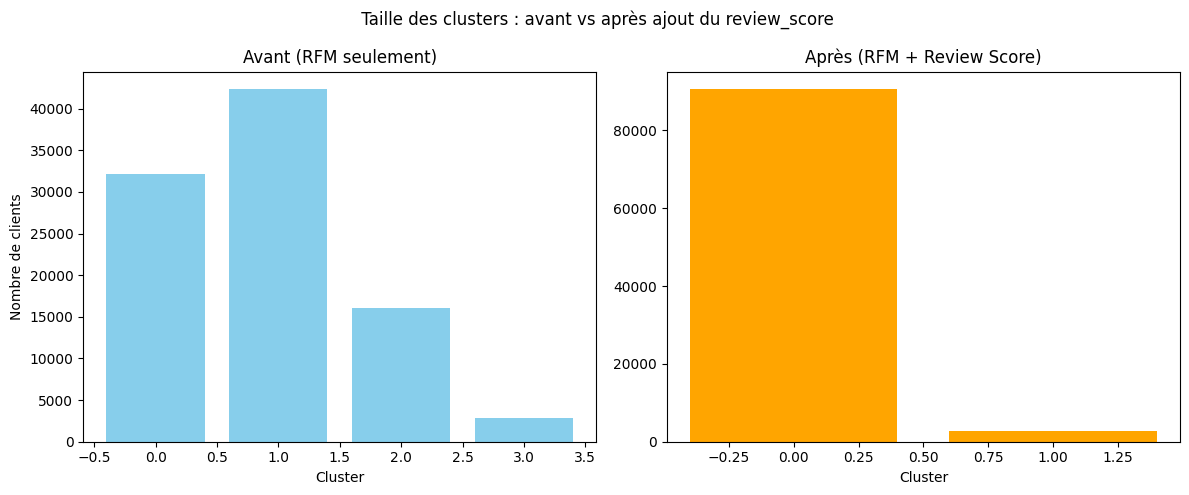

In [19]:

# === Données avant (RFM seul) ===
rfm = pd.DataFrame({
    'cluster': [0, 1, 2, 3],
    'n_clients': [32201, 42323, 16033, 2801],
    'R_med': [254, 269, 37, 199],
    'F_med': [1, 1, 1, 2],
    'M_med': [199.27, 65.84, 103.89, 225.55],
})

# === Données après (RFM + review_score) ===
rfm_ext = pd.DataFrame({
    'cluster': [0, 1],
    'n_clients': [90557, 2801],
    'R_med': [219, 199],
    'F_med': [1, 2],
    'M_med': [105.38, 225.55],
    'review_score_med': [5.00, 4.67],
})


# Taille des clusters

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].bar(rfm['cluster'], rfm['n_clients'], color='skyblue')
ax[0].set_title("Avant (RFM seulement)")
ax[0].set_xlabel("Cluster")
ax[0].set_ylabel("Nombre de clients")

ax[1].bar(rfm_ext['cluster'], rfm_ext['n_clients'], color='orange')
ax[1].set_title("Après (RFM + Review Score)")
ax[1].set_xlabel("Cluster")

plt.suptitle(" Taille des clusters : avant vs après ajout du review_score")
plt.tight_layout()
plt.show()




Export des segments finaux

In [ ]:
# ANALYSE : Est-ce que le review_score améliore notre segmentation ?

print("="*50)
print("ANALYSE DE L'AJOUT DU REVIEW SCORE")
print("="*50)

# Comparer avant/après
print("\nComparaison des résultats :")
print("-" * 30)
print("SANS review_score : 4 clusters")
print("  - Cluster 0 : 32,201 clients")
print("  - Cluster 1 : 42,323 clients") 
print("  - Cluster 2 : 16,033 clients")
print("  - Cluster 3 : 2,801 clients")

print("\nAVEC review_score : 2 clusters")
print("  - Cluster 0 : 90,557 clients (97%)")
print("  - Cluster 1 : 2,801 clients (3%)")

# Analyse simple
print("\nProblèmes identifiés :")
print("1. On passe de 4 à 2 clusters → moins de précision")
print("2. 97% des clients dans un seul groupe → segmentation inutile")
print("3. Les reviews sont toutes entre 4 et 5 → pas de différence")

# Décision
print("\nDécision : NE PAS utiliser le review_score")
print("Le modèle RFM seul est meilleur pour segmenter les clients")

# Export du fichier CSV
print("\n" + "="*50)
print("EXPORT DES DONNÉES")
print("="*50)


# Créer le dossier exports
if not os.path.exists('./exports'):
    os.makedirs('./exports')
    print("Dossier 'exports' créé")

# Préparer les données pour l'export (sans review_score)
colonnes_a_garder = ['customer_unique_id', 'recency', 'frequency', 'monetary', 'cluster', 'segment_nom']

# Sélectionner seulement les colonnes qui existent
colonnes_finales = []
for col in colonnes_a_garder:
    if col in df_clustering.columns:
        colonnes_finales.append(col)

# Créer le DataFrame final
df_export = df_clustering[colonnes_finales].copy()

# Sauvegarder en CSV
fichier = './exports/segmentation_clients_rfm.csv'
df_export.to_csv(fichier, index=False)

print(f"Fichier sauvegardé : {fichier}")
print(f"Nombre de clients : {len(df_export)}")
print(f"Colonnes exportées : {', '.join(colonnes_finales)}")

# Afficher les premières lignes
print("\nAperçu du fichier exporté :")
print(df_export.head(3))

ANALYSE DE L'AJOUT DU REVIEW SCORE

Comparaison des résultats :
------------------------------
SANS review_score : 4 clusters
  - Cluster 0 : 32,201 clients
  - Cluster 1 : 42,323 clients
  - Cluster 2 : 16,033 clients
  - Cluster 3 : 2,801 clients

AVEC review_score : 2 clusters
  - Cluster 0 : 90,557 clients (97%)
  - Cluster 1 : 2,801 clients (3%)

Problèmes identifiés :
1. On passe de 4 à 2 clusters → moins de précision
2. 97% des clients dans un seul groupe → segmentation inutile
3. Les reviews sont toutes entre 4 et 5 → pas de différence

Décision : NE PAS utiliser le review_score
Le modèle RFM seul est meilleur pour segmenter les clients

EXPORT DES DONNÉES
Fichier sauvegardé : ./exports/segmentation_clients_rfm.csv
Nombre de clients : 93358
Colonnes exportées : customer_unique_id, recency, frequency, monetary, cluster, segment_nom

Aperçu du fichier exporté :
                 customer_unique_id  recency  frequency  monetary  cluster  \
0  0000366f3b9a7992bf8c76cfdf3221e2      1